最終課題＿オリジナルAIの構築

In [1]:
!pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path:", path)

Path: C:\Users\boobo\.cache\kagglehub\datasets\tongpython\cat-and-dog\versions\1


In [2]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 10028 files belonging to 2 classes.
Using 8023 files for training.
Found 10028 files belonging to 2 classes.
Using 2005 files for validation.


In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 183ms/step - accuracy: 0.7942 - loss: 0.5961 - val_accuracy: 0.7985 - val_loss: 0.5128
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 44s 177ms/step - accuracy: 0.7982 - loss: 0.5132 - val_accuracy: 0.7985 - val_loss: 0.5138
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 180ms/step - accuracy: 0.7981 - loss: 0.5015 - val_accuracy: 0.7985 - val_loss: 0.5342
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 45s 181ms/step - accuracy: 0.7988 - loss: 0.4595 - val_accuracy: 0.7955 - val_loss: 0.5794
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.8210 - loss: 0.4030 - val_accuracy: 0.7721 - val_loss: 0.7633


In [4]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.8570 - loss: 0.3386 - val_accuracy: 0.7446 - val_loss: 0.7220
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 51s 202ms/step - accuracy: 0.8942 - loss: 0.2591 - val_accuracy: 0.7576 - val_loss: 0.9914
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 201ms/step - accuracy: 0.9261 - loss: 0.1903 - val_accuracy: 0.7416 - val_loss: 1.1236
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.9530 - loss: 0.1287 - val_accuracy: 0.7466 - val_loss: 1.4586
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.9697 - loss: 0.0927 - val_accuracy: 0.7287 - val_loss: 1.7860
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 196ms/step - accuracy: 0.9782 - loss: 0.0696 - val_accuracy: 0.7491 - val_loss: 2.0860
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.9804 - loss: 0.0584 - val_accuracy: 0.7062 - val_loss: 1.9185
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 50s 198ms/step - accuracy: 0.9824 - loss: 0

In [5]:
loss, accuracy = model.evaluate(val_ds)
print(f"評価結果 - 損失: {loss:.4f}, 精度: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7312 - loss: 2.2197
評価結果 - 損失: 2.2197, 精度: 0.7312


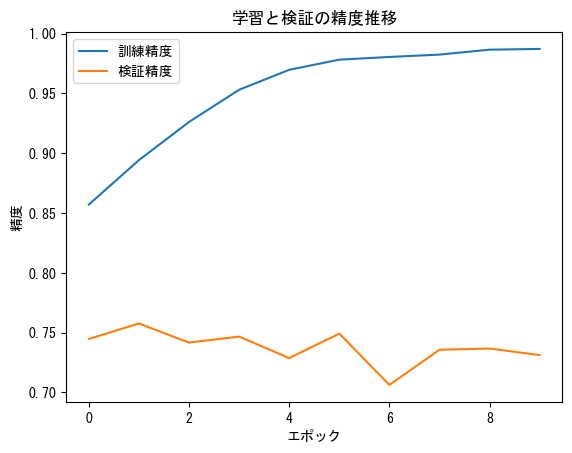

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'MS Gothic'

plt.plot(history.history['accuracy'], label='訓練精度')
plt.plot(history.history['val_accuracy'], label='検証精度')
plt.xlabel('エポック')
plt.ylabel('精度')
plt.legend()
plt.title('学習と検証の精度推移')
plt.show()

In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Dataset → NumPy
x = []
y = []

for images, labels in train_ds.unbatch().as_numpy_iterator():
    x.append(images)
    y.append(labels)

x = np.array(x)
y = np.array(y)

# train/test 分割
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True
)

# 画像を1次元に変換
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# RandomForest で学習
model = RandomForestClassifier()
model.fit(X_train_flat, y_train)

# 予測
y_pred = model.predict(X_test_flat)

# 精度
accuracy = accuracy_score(y_test, y_pred)
print("精度:", accuracy)





精度: 0.7862928348909657
